<a href="https://colab.research.google.com/github/kumudvi/Netflix-and-movies/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2. Load the Dataset

In [2]:
df = pd.read_csv('/content/netflix_titles.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# 3. Data Exploration

### Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Missing values

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64


### Percentage of missing values

In [6]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064
show_id,0.000000
type,0.000000
title,0.000000
release_year,0.000000


### Statistical summary

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Data Cleaning

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [9]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [10]:
text_columns = ['director', 'cast', 'country', 'rating', 'listed_in', 'description']

for col in text_columns:
    df[col] = df[col].fillna('Unknown')

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,3


# DATA VISUALIZATION

## 5. Movies vs TV Shows

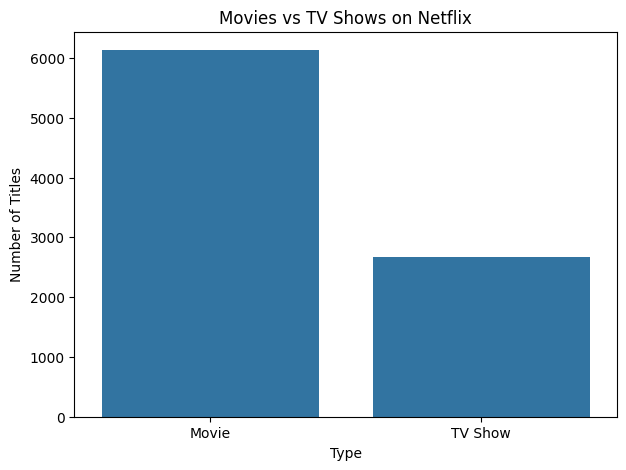

In [12]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.show()

## 6. Movies vs TV Shows — Pie Chart

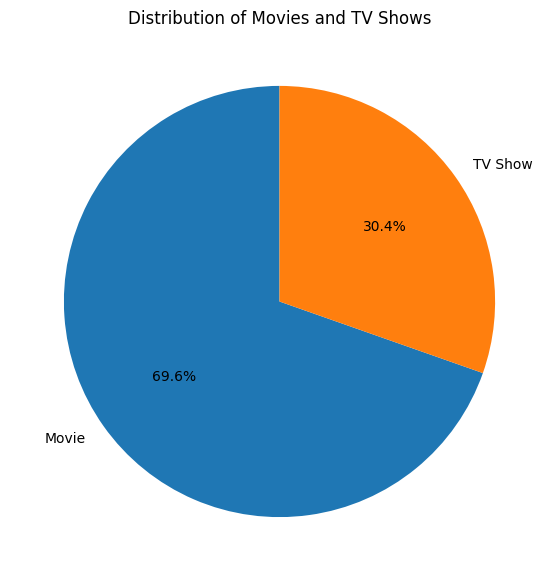

In [13]:
plt.figure(figsize=(7,7))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Movies and TV Shows')
plt.ylabel('')
plt.show()

## 7. Titles Added to Netflix by Year

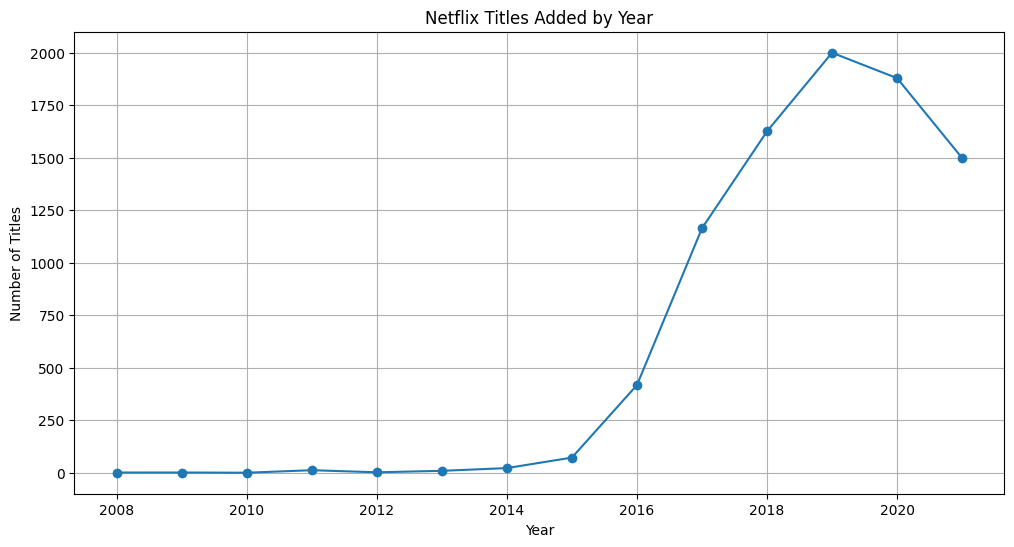

In [14]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values, marker='o')

plt.title('Netflix Titles Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

## 8. Content Released by Year

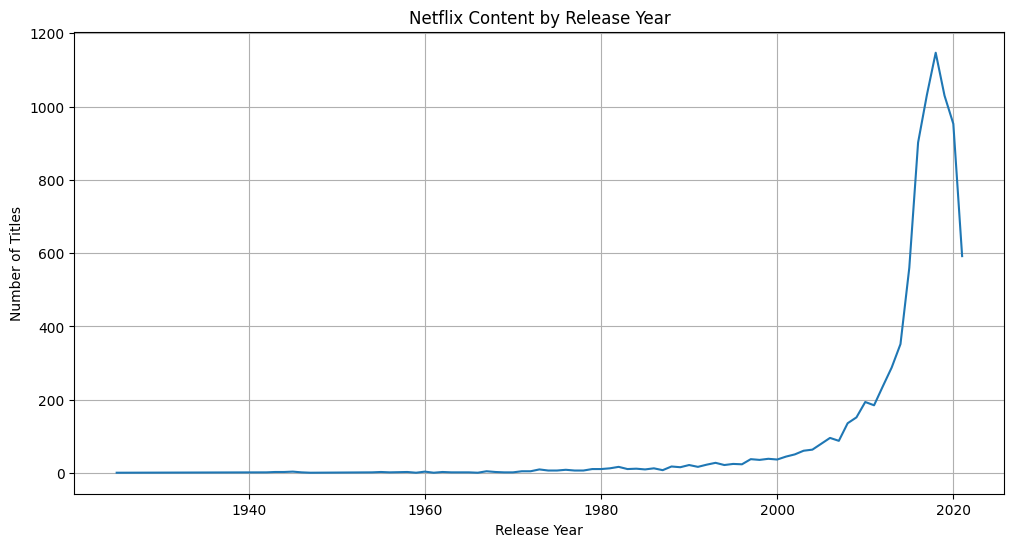

In [15]:
release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(release_counts.index, release_counts.values)

plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

## 9. Top 10 Ratings

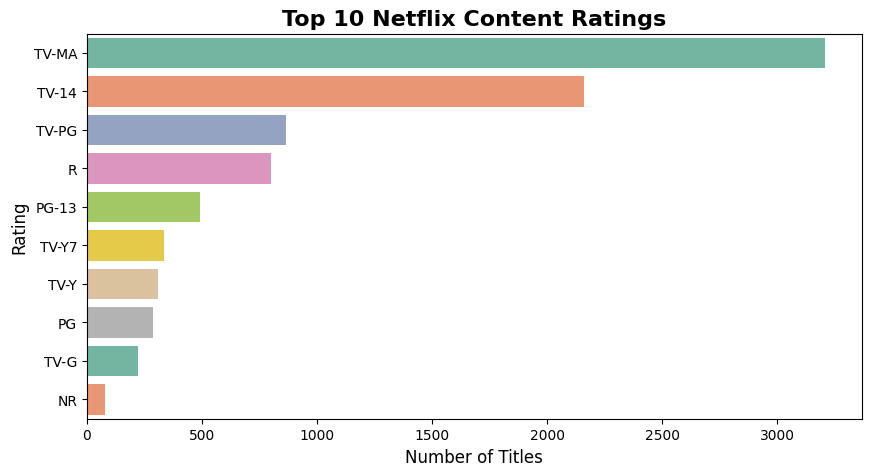

In [43]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette='Set2',
    legend=False
)

plt.title('Top 10 Netflix Content Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Rating', fontsize=12)

plt.show()

## 10. Top Countries Producing Netflix Content

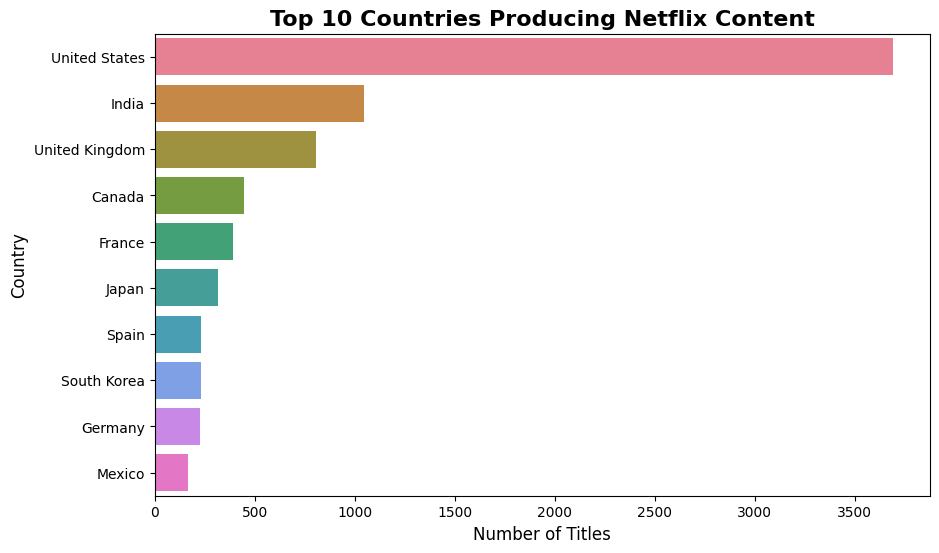

In [44]:
countries = df['country'].str.split(', ').explode()

country_counts = countries[countries != 'Unknown'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    hue=country_counts.index,
    palette='husl',
    legend=False
)

plt.title('Top 10 Countries Producing Netflix Content',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.show()

## 11. Top Genres

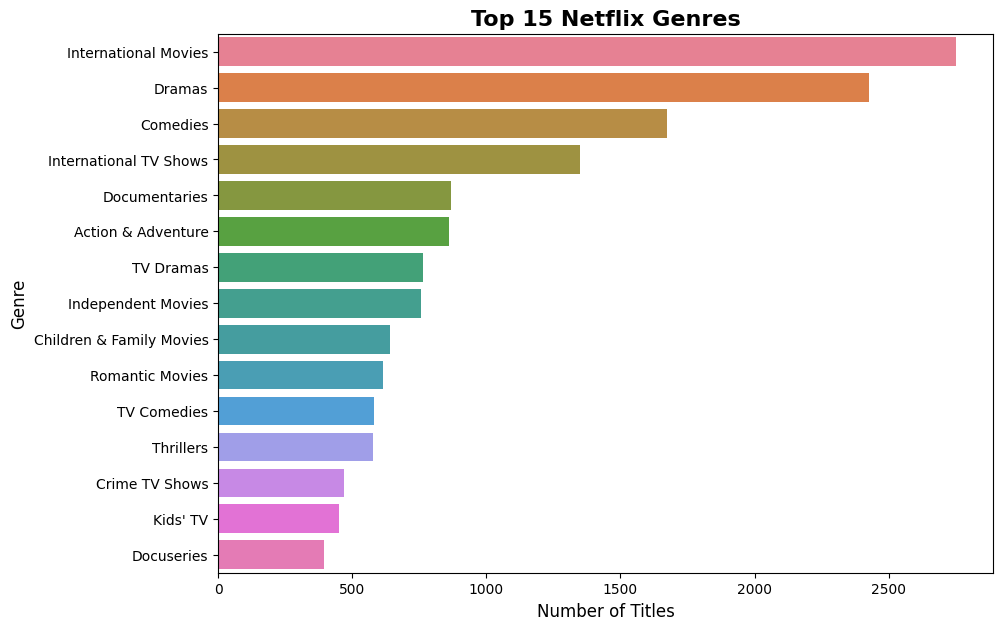

In [45]:
genres = df['listed_in'].str.split(', ').explode()

genre_counts = genres[genres != 'Unknown'].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    palette='husl',
    legend=False
)

plt.title('Top 15 Netflix Genres',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.show()

# NLP TECHNIQUES

## 12. Text Preprocessing

In [19]:
nlp_df = df[['title', 'description']].copy()

nlp_df['description'] = nlp_df['description'].fillna('')

In [20]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)

nlp_df['clean_description'] = nlp_df['description'].apply(clean_text)

nlp_df.head()

,title,description,clean_description
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",father nears end life filmmaker kirsten johnso...
1,Blood & Water,"After crossing paths at a party, a Cape Town t...",crossing paths party cape town teen sets prove...
2,Ganglands,To protect his family from a powerful drug lor...,protect family powerful drug lord skilled thie...
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",feuds flirtations toilet talk among incarcerat...
4,Kota Factory,In a city of coaching centers known to train I...,city coaching centers known train indias fines...


## 13. Tokenization


In [21]:
nltk.download('punkt')

nlp_df['tokens'] = nlp_df['clean_description'].apply(word_tokenize)

nlp_df[['title', 'tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,title,tokens
0,Dick Johnson Is Dead,"[father, nears, end, life, filmmaker, kirsten,..."
1,Blood & Water,"[crossing, paths, party, cape, town, teen, set..."
2,Ganglands,"[protect, family, powerful, drug, lord, skille..."
3,Jailbirds New Orleans,"[feuds, flirtations, toilet, talk, among, inca..."
4,Kota Factory,"[city, coaching, centers, known, train, indias..."


## 14. Word Frequency Analysis

In [22]:
all_words = []

for tokens in nlp_df['tokens']:
    all_words.extend(tokens)

word_frequency = Counter(all_words)

word_frequency.most_common(20)

[('life', 774),
 ('young', 728),
 ('new', 699),
 ('family', 570),
 ('love', 497),
 ('two', 495),
 ('man', 491),
 ('world', 491),
 ('friends', 466),
 ('woman', 452),
 ('must', 398),
 ('series', 395),
 ('documentary', 361),
 ('one', 346),
 ('find', 341),
 ('finds', 313),
 ('school', 312),
 ('home', 306),
 ('three', 292),
 ('help', 291)]

## 15. Most Common Words Visualization

/tmp/ipykernel_1183/211801723.py:63: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


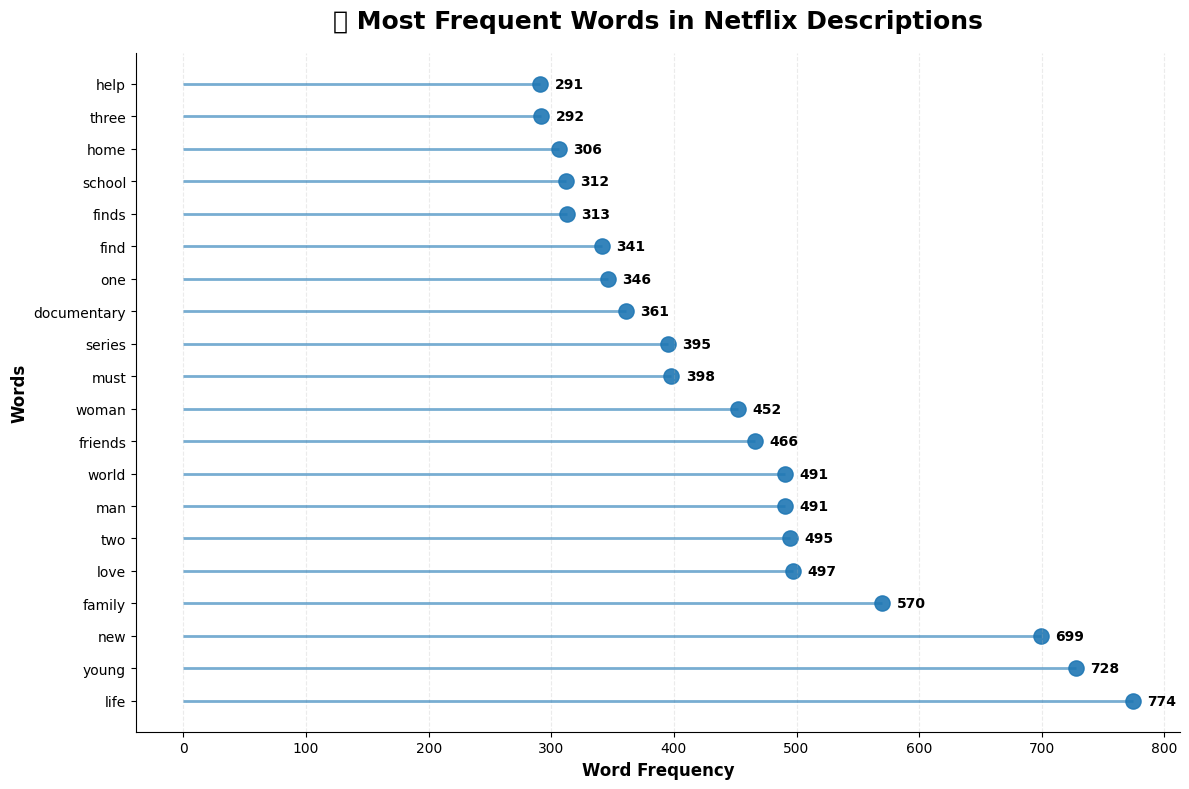

In [53]:
common_words = word_frequency.most_common(20)

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12, 8))

# Draw lines
plt.hlines(
    y=words,
    xmin=0,
    xmax=counts,
    linewidth=2,
    alpha=0.6
)

# Draw circles
plt.scatter(
    counts,
    words,
    s=120,
    alpha=0.9
)

# Add frequency labels
for word, count in zip(words, counts):
    plt.text(
        count + max(counts) * 0.015,
        word,
        f'{count:,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    '🔤 Most Frequent Words in Netflix Descriptions',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Word Frequency',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Words',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

## 16. Word Cloud

In [24]:
from wordcloud import WordCloud

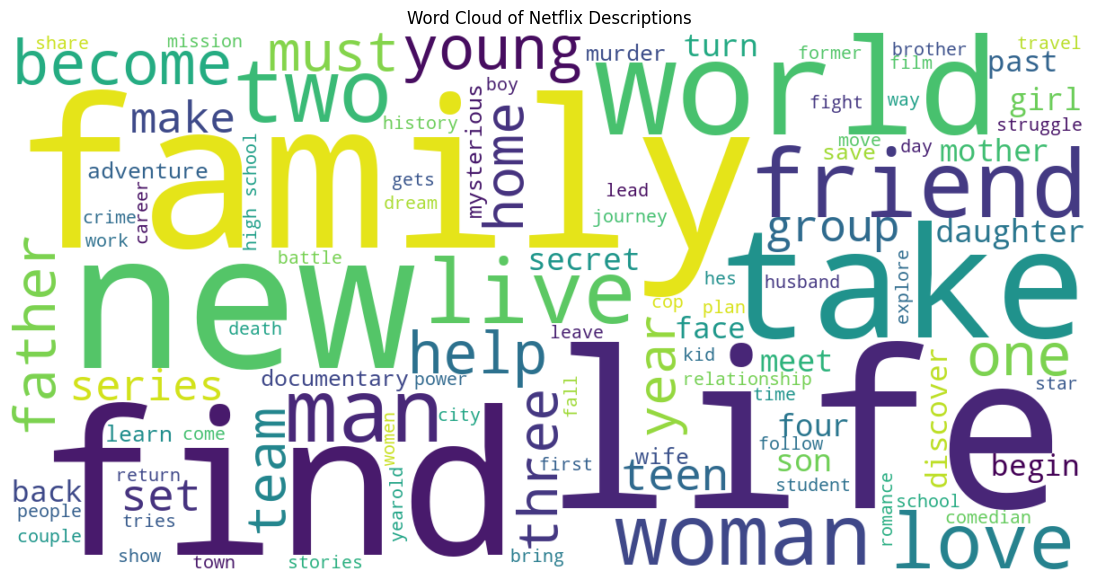

In [25]:
all_text = ' '.join(nlp_df['clean_description'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(all_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Netflix Descriptions')
plt.show()

## 17. TF-IDF

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    nlp_df['clean_description']
)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (8807, 5000)


In [28]:
tfidf_words = tfidf.get_feature_names_out()

print(tfidf_words[:20])

['aaron' 'abandoned' 'abandons' 'abduct' 'abducted' 'abduction' 'abducts'
 'abilities' 'ability' 'able' 'aboard' 'abound' 'abroad' 'abruptly'
 'absence' 'absurd' 'abuse' 'abusive' 'academic' 'academy']


## 18. TF-IDF Based Similarity

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (8807, 8807)


In [30]:
similarity_scores = list(enumerate(similarity_matrix[0]))

similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

similarity_scores[:10]

[(0, np.float64(1.0)),
 (6327, np.float64(0.2254729170993669)),
 (7506, np.float64(0.17462108743655233)),
 (2429, np.float64(0.17333185788099556)),
 (8700, np.float64(0.15703897516993753)),
 (3614, np.float64(0.15694318671512014)),
 (4241, np.float64(0.15280922930465293)),
 (1946, np.float64(0.1507647730178153)),
 (5494, np.float64(0.14895737128211078)),
 (1872, np.float64(0.14757263124858594))]

In [31]:
for index, score in similarity_scores[1:10]:
    print(nlp_df.iloc[index]['title'], "->", round(score, 3))

Black Snake Moan -> 0.225
Moon -> 0.175
Can’t Complain -> 0.173
Wartime Portraits -> 0.157
Reply 1997 -> 0.157
Secrets in the Hot Spring -> 0.153
Welcome -> 0.151
Kazoops! -> 0.149
The Forty-Year-Old Version -> 0.148


## 19. Bigrams

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=20
)

bigram_matrix = bigram_vectorizer.fit_transform(
    nlp_df['clean_description']
)

bigram_counts = bigram_matrix.sum(axis=0)

bigrams = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)

bigrams[:20]

[('high school', np.int64(140)),
 ('young man', np.int64(108)),
 ('young woman', np.int64(103)),
 ('new york', np.int64(95)),
 ('best friends', np.int64(60)),
 ('true story', np.int64(57)),
 ('world war', np.int64(51)),
 ('based true', np.int64(49)),
 ('best friend', np.int64(49)),
 ('standup special', np.int64(48)),
 ('los angeles', np.int64(46)),
 ('documentary follows', np.int64(42)),
 ('falls love', np.int64(40)),
 ('york city', np.int64(39)),
 ('documentary series', np.int64(36)),
 ('social media', np.int64(35)),
 ('road trip', np.int64(35)),
 ('serial killer', np.int64(34)),
 ('martial arts', np.int64(33)),
 ('reality series', np.int64(30))]

## 20. N-Gram Visualization

/tmp/ipykernel_1183/1578821926.py:34: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


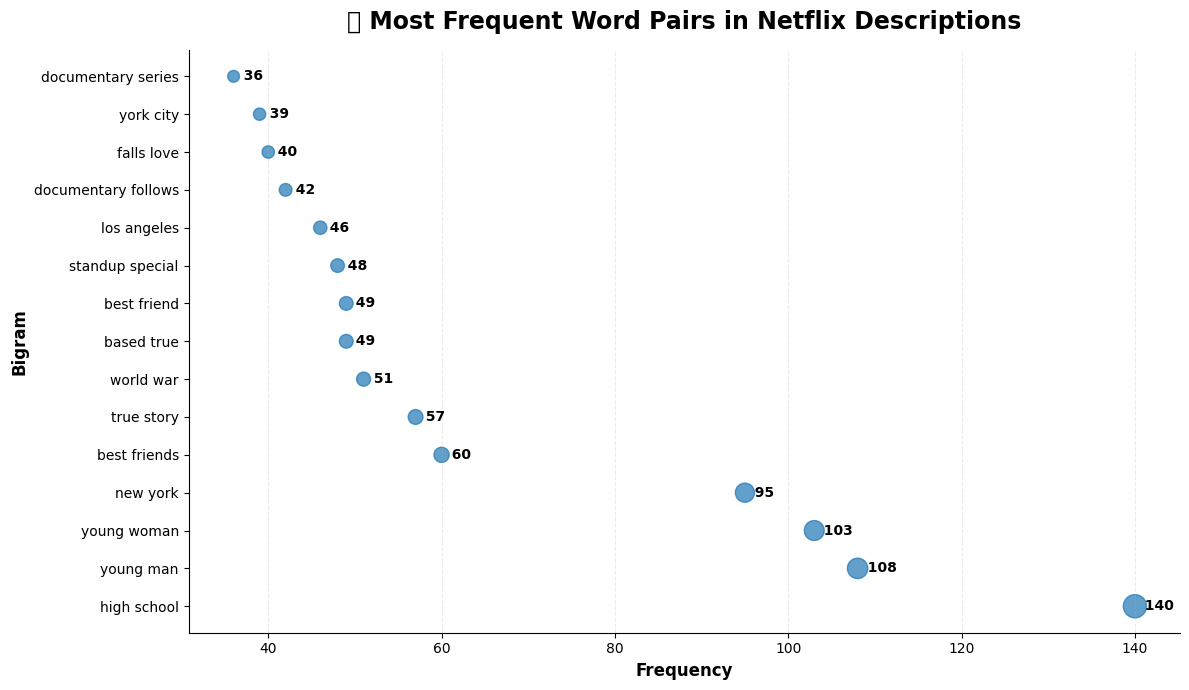

In [52]:
plt.figure(figsize=(12, 7))

plt.scatter(
    bigram_values,
    bigram_words,
    s=[v * 2 for v in bigram_values],
    alpha=0.7
)

for x, y, value in zip(bigram_values, bigram_words, bigram_values):
    plt.text(
        x,
        y,
        f'  {value:,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    '💬 Most Frequent Word Pairs in Netflix Descriptions',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Frequency', fontsize=12, fontweight='bold')
plt.ylabel('Bigram', fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.25)

sns.despine()

plt.tight_layout()
plt.show()

## 21. Sentiment Analysis

In [34]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [35]:
nlp_df['sentiment_score'] = nlp_df['description'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [36]:
def sentiment_category(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

nlp_df['sentiment'] = nlp_df['sentiment_score'].apply(
    sentiment_category
)

nlp_df[['title', 'sentiment_score', 'sentiment']].head()

,title,sentiment_score,sentiment
0,Dick Johnson Is Dead,-0.2960,Negative
1,Blood & Water,-0.1531,Negative
2,Ganglands,-0.7783,Negative
3,Jailbirds New Orleans,0.2263,Positive
4,Kota Factory,0.7430,Positive


/tmp/ipykernel_1183/1989639285.py:50: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


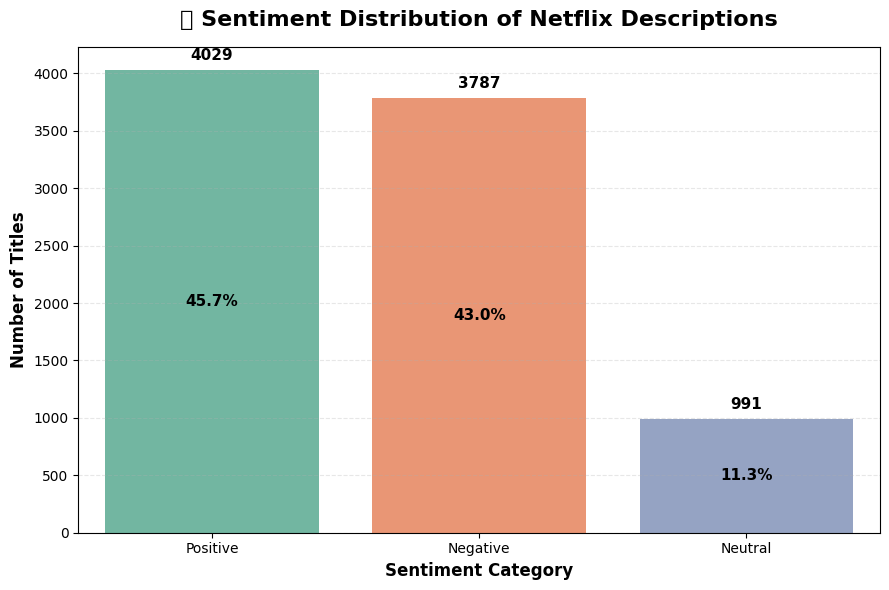

In [47]:
sentiment_counts = nlp_df['sentiment'].value_counts()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette='Set2',
    legend=False
)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=5,
        fontsize=11,
        fontweight='bold'
    )

# Calculate percentages
total = sentiment_counts.sum()

for i, value in enumerate(sentiment_counts.values):
    percentage = (value / total) * 100
    ax.text(
        i,
        value / 2,
        f'{percentage:.1f}%',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    '🎭 Sentiment Distribution of Netflix Descriptions',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Sentiment Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Titles', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Word Frequency by Movie vs TV Show

In [38]:
analysis_df = df[['title', 'type', 'description']].copy()

analysis_df['description'] = analysis_df['description'].fillna('')

analysis_df['clean_description'] = analysis_df['description'].apply(clean_text)

In [39]:
analysis_df['description_length'] = analysis_df['clean_description'].apply(
    lambda x: len(x.split())
)

analysis_df.groupby('type')['description_length'].mean()

,description_length
type,
Movie,14.265536
TV Show,14.275411


/tmp/ipykernel_1183/9117589.py:28: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


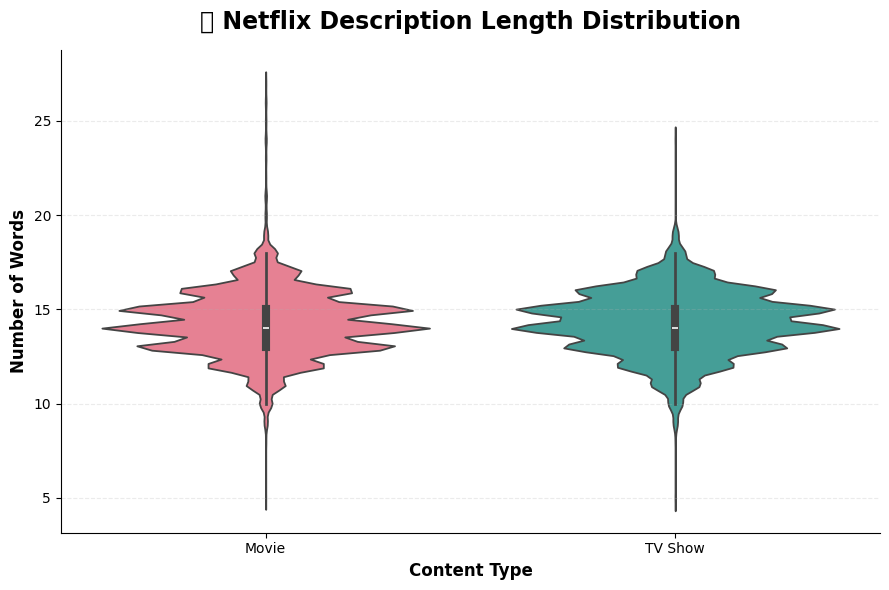

In [50]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=analysis_df,
    x='type',
    y='description_length',
    hue='type',
    palette='husl',
    legend=False,
    inner='box',
    linewidth=1.3
)

plt.title(
    '🎭 Netflix Description Length Distribution',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Content Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Words', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.25)

sns.despine()

plt.tight_layout()
plt.show()

## 23. Correlation Heatmap

In [41]:
analysis_df['word_count'] = analysis_df['clean_description'].apply(
    lambda x: len(x.split())
)

analysis_df['character_count'] = analysis_df['description'].apply(
    len
)

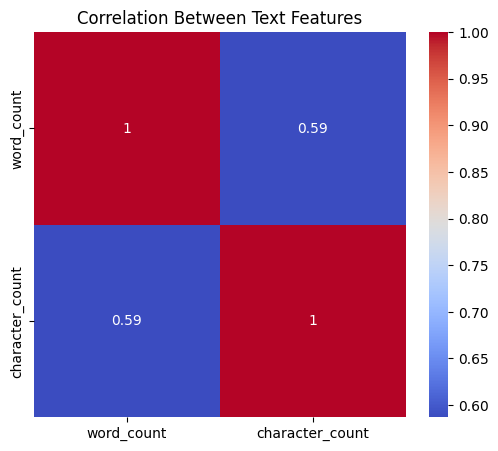

In [42]:
correlation = analysis_df[
    ['word_count', 'character_count']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Text Features')
plt.show()